Iteration    0 | Loss: 27.5449
Iteration  100 | Loss: 3.5992
Iteration  200 | Loss: 0.5298
Iteration  300 | Loss: 0.1104
Iteration  400 | Loss: 0.0487
Iteration  500 | Loss: 0.0360
Iteration  600 | Loss: 0.0308
Iteration  700 | Loss: 0.0270
Iteration  800 | Loss: 0.0238
Iteration  900 | Loss: 0.0210

Final weights (theta):
[ 7.24382401  0.10582778  0.0975767   0.09003544  0.08655137  0.0769606
  0.06894588  0.0686181   0.06128001  0.91609734  0.01638014  0.03233262
  0.04448917 -0.04826922 -0.07161728 -0.02966233  0.09897831 -0.04359581
  0.19002993 -0.08870767 -0.00786097 -0.04803946 -0.01608455]

Test MSE : 0.0389
Test R^2 : 0.9850

Sklearn Linear Regression Results:
Sklearn MSE : 0.0000
Sklearn R^2 : 1.0000

Saved plots to gradient_descent_plots.png


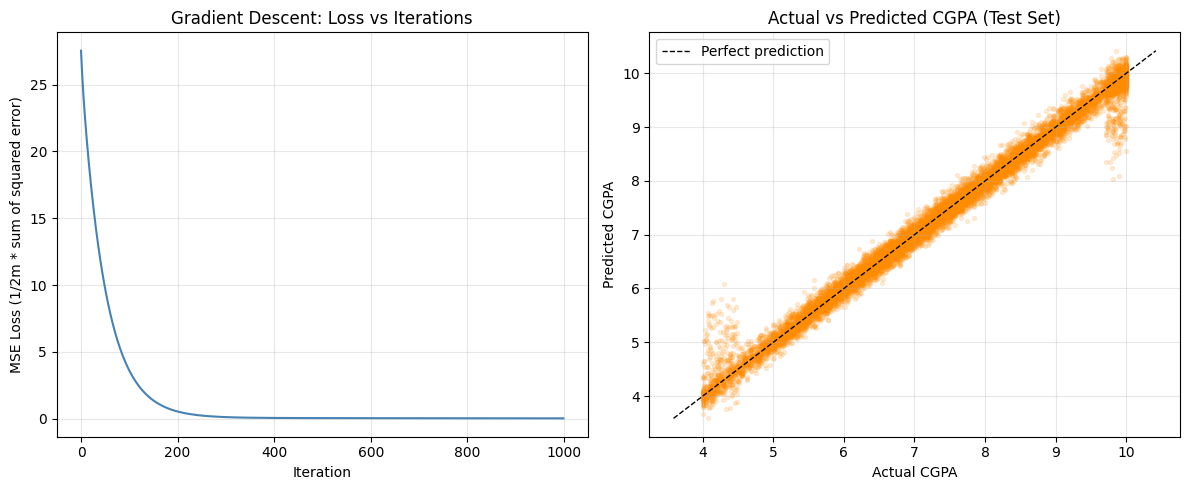

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
df = pd.read_csv("/content/placement_predict_50k Dataset (1) (1).csv")
target_col = "CGPA"
drop_cols = ["StudentID", "CGPA_Tier"]

feature_df = df.drop(columns=drop_cols, errors="ignore")
feature_df = feature_df.select_dtypes(include=[np.number])
feature_df = feature_df.fillna(feature_df.median())
X = feature_df.values
y = df[target_col].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train_b = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_b = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]



def gradient_descent(X, y, lr=0.01, n_iters=1000):

    m, n = X.shape


    theta = np.zeros((n, 1))

    losses = []

    for i in range(n_iters):

        y_pred = X @ theta

        error = y_pred - y

        loss = (1 / (2 * m)) * np.sum(error ** 2)

        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)


        theta = theta - lr * gradient


        if i % 100 == 0:
            print(
                f"Iteration {i:4d} | Loss: {loss:.4f}"
            )

    return theta, losses
theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)


y_pred = X_test_b @ theta

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")


sk_model = LinearRegression()

sk_model.fit(X_train, y_train.ravel())

sk_pred = sk_model.predict(X_test)

sk_mse = mean_squared_error(y_test, sk_pred)
sk_r2 = r2_score(y_test, sk_pred)

print("\nSklearn Linear Regression Results:")
print(f"Sklearn MSE : {sk_mse:.4f}")
print(f"Sklearn R^2 : {sk_r2:.4f}")


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)




axes[0].plot(
    range(len(losses)),
    losses,
    color="steelblue"
)

axes[0].set_title(
    "Gradient Descent: Loss vs Iterations"
)

axes[0].set_xlabel("Iteration")

axes[0].set_ylabel(
    "MSE Loss (1/2m * sum of squared error)"
)

axes[0].grid(alpha=0.3)



axes[1].scatter(
    y_test,
    y_pred,
    alpha=0.15,
    s=8,
    color="darkorange"
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[1].plot(
    lims,
    lims,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)
axes[1].set_title(
    "Actual vs Predicted CGPA (Test Set)"
)

axes[1].set_xlabel("Actual CGPA")

axes[1].set_ylabel("Predicted CGPA")

axes[1].legend()

axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "gradient_descent_plots.png",
    dpi=150
)

print(
    "\nSaved plots to gradient_descent_plots.png"
)

plt.show()
